In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import os
import pandas as pd
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import os
import json
import math
import pickle
import matplotlib.pyplot as plt
from IPython.display import clear_output
from scipy.ndimage import gaussian_filter
from matplotlib.gridspec import GridSpec

from matplotlib.patches import Rectangle

from bioplnn.models import SpatiallyEmbeddedClassifier, SpatiallyEmbeddedAreaConfig, SpatiallyEmbeddedRNN, Ablation
from bioplnn.datasets import Mazes
from bioplnn.utils import (
    initialize_dataloader,
)

maze_data_path = "./data/mazes/"
checkpoint_path = "./train/checkpoints/"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

In [11]:
def activation_helper(model, num_samples, dataloader, type):
    num_save_steps = 20

    # num_samples = len(dataloader.dataset) if hasattr(dataloader, 'dataset') else sum(1 for _ in dataloader)
    activations = np.zeros((num_samples, num_save_steps, (4 if type=="i" else 8), 48, 48), dtype=np.float32)

    with torch.no_grad():
        # # record activations
        sample_idx = 0
        for batch_inputs, label in tqdm(dataloader):
            # input: (batch_size, channels, H, W)
            batch_size = batch_inputs.shape[0]
            batch_inputs = batch_inputs.to(device)
            batch_output_states, batch_neuron_states, batch_feedback_states = model(batch_inputs, num_steps=num_save_steps)

            if type=="o":
                activity = batch_output_states[0].detach().cpu().numpy()
            else:
                activity = model.query_neuron_states(batch_neuron_states, 0, 0 if type=="e" else 1).detach().cpu().numpy()

            activations[sample_idx:sample_idx+batch_size, :, :, :, :] = activity
            sample_idx += batch_size
    
    return activations
    
def decision_helper(classifier, dataloader, decision_step):
    # # # record decisions
    decisions = []
    classifier.to(device)
    with torch.no_grad():
        for batch_inputs, label in tqdm(dataloader):
            # input: (batch_size, channels, H, W)
            batch_size = batch_inputs.shape[0]
            batch_inputs = batch_inputs.to(device)
            pred = classifier(batch_inputs, num_steps=decision_step)
            decisions.extend(torch.argmax(pred, dim=-1).detach().tolist())
    decisions = np.array(decisions)
    return decisions

def get_activations(model, classifier, num_samples, loader, decision_step):
    all_indices = np.arange(len(loader.dataset))
    subset_indices = np.random.choice(all_indices, size=num_samples, replace=False)

    # wrap dataset
    subset_dataset = Subset(loader.dataset, subset_indices)

    # create a new DataLoader
    dataloader = DataLoader(
        subset_dataset,
        batch_size=loader.batch_size,
        shuffle=False,              # usually keep consistent
        num_workers=loader.num_workers,
        pin_memory=True if hasattr(loader, "pin_memory") else False
    )

    e_a = activation_helper(model, num_samples, dataloader, "e")
    i_a = activation_helper(model, num_samples, dataloader, "i")
    o_a = activation_helper(model, num_samples, dataloader, "o")
    decisions = decision_helper(classifier, dataloader, decision_step)
    return e_a, i_a, o_a, decisions

In [4]:
def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    
def load_model_and_config(wandb_name, checkpoint_path):
    """Load model configuration and instantiate models."""
    try:
        full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        model_cfg, num_steps = full_cfg["model_config"], full_cfg["num_steps"]
    except:
        model_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        num_steps = 20

    model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
    classifier = SpatiallyEmbeddedClassifier(**model_cfg)
    mazes = Mazes(maze_data_path)
    
    return model, classifier, mazes, num_steps

In [5]:
# ReLU, with I->I recurrence, BEST
wandb_name = "golden-universe-515"
checkpoint = 320

# ——— Load model config & instantiate ———
model, classifier, mazes, num_steps = load_model_and_config(wandb_name, checkpoint_path)
model.to(device)
model.eval()

# ——— Load checkpoint & weights ———
try:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
except:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))
try:
    state_dict = state_dict["model_state"]
except:
    pass

model.load_state_dict(prepare_rnn_weights(state_dict))
classifier.load_state_dict(state_dict)

/tmp/ipykernel_4166949/2687229834.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locati

<All keys matched successfully>

In [6]:
batch_size = 512
num_samples = batch_size * 20
dataset = "mazes"
train_loader, test_loader = initialize_dataloader(
    seed=42, root=maze_data_path, batch_size=batch_size, dataset=dataset
)

In [7]:
decision_step = 20
train_ea, train_ia, train_oa, train_decisions = get_activations(model, classifier, num_samples, train_loader, decision_step)
# test_ea, test_ia, test_oa, test_decisions = get_activations(model, classifier, num_samples//5, test_loader, decision_step)

100%|██████████| 20/20 [00:08<00:00,  2.50it/s]


In [ ]:
# merge activations
e_activations = np.max(ea.reshape(ea.shape[0], ea.shape[1], ea.shape[2], -1), axis=-1)
i_activations = np.max(ia.reshape(ia.shape[0], ia.shape[1], ia.shape[2], -1), axis=-1)
o_activations = np.max(oa.reshape(oa.shape[0], oa.shape[1], oa.shape[2], -1), axis=-1)

test_activations = np.concatenate((e_activations, i_activations, o_activations), axis=2)

In [20]:
import math, numpy as np, torch
from typing import List, Dict, Optional, Tuple

# ----- simple logistic reg -----
class LogisticReg:
    def __init__(self, D, l2=1e-3): self.W=torch.zeros(D,1); self.b=torch.zeros(1); self.l2=l2
    def fit(self,X,y,lr=0.1,steps=800,bs=4096):
        X=X.contiguous(); y=y.view(-1,1).contiguous()
        N,D=X.shape; self.W=self.W.to(X); self.b=self.b.to(X); self.W.requires_grad_(True); self.b.requires_grad_(True)
        opt=torch.optim.Adam([self.W,self.b],lr=lr); lossfn=torch.nn.BCEWithLogitsLoss()
        for _ in range(steps):
            if bs>=N: xb,yb=X,y
            else:
                idx=torch.randint(0,N,(bs,),device=X.device); xb,yb=X[idx],y[idx]
            logits=xb@self.W+self.b
            loss=lossfn(logits,yb)+self.l2*self.W.square().sum()
            opt.zero_grad(); loss.backward(); opt.step()
    @torch.no_grad()
    def margin(self,X): return (X@self.W+self.b).view(-1)  # logit for class 1

# ----- helpers -----
def _logit(p): p=min(max(p,1e-6),1-1e-6); return math.log(p/(1-p))

def find_tc_from_margins(margin_t: np.ndarray, final_decision: int,
                         p_thresh: float=0.9, k_persist: int=3) -> Optional[int]:
    """margin_t: [T] (logit for class-1). Use final model decision (0/1) to set sign."""
    theta=_logit(p_thresh); sign=1 if final_decision==1 else -1
    s=sign*margin_t  # signed margin for the final decision class
    T=len(s)
    for t in range(0,T-k_persist+1):
        if np.all(s[t:t+k_persist] >= theta) and np.all(s[t:] >= 0.0):
            return t
    return None  # censored

# ----- main API -----
def estimate_tc_and_tau_probes(
    acts: np.ndarray,              # [N,T,D] from one population
    labels_final: np.ndarray,      # [N] final model decisions (0/1)
    late_K: int=4, p_thresh: float=0.9, k_persist: int=3,
    min_samples_per_class: int=100, taus: Optional[List[int]]=None,
    l2: float=1e-3, lr: float=0.1, steps_tc: int=1000, steps_tau: int=600, seed: int=0, 
    decision_step=None,
) -> Tuple[List[Optional[int]], Dict[int, Dict[str, object]]]:
    """
    1) Train a single late-window probe on t ∈ [T-late_K, T-1] using labels_final.
    2) Use its per-time margins to get per-trial t_c (first-crossing + persistence, no later flips).
    3) Event-lock by tau=t-t_c and train a probe for each tau (predicting labels_final).
    Returns: (tc_list, tau_probes_dict), where tau_probes_dict[tau] has keys W, b, n, class_counts.
    """
    rng=np.random.default_rng(seed)
    X=torch.as_tensor(acts, dtype=torch.float32)
    y=torch.as_tensor(labels_final, dtype=torch.float32)
    N,T,D=X.shape
    if decision_step is None:
        decision_step = T

    # --- late-window probe (fixed decision axis) ---
    X_late = X[:, decision_step-late_K:decision_step, :].reshape(-1, D)
    y_late = y.repeat_interleave(late_K)
    clf = LogisticReg(D, l2=l2); clf.fit(X_late, y_late, lr=lr, steps=steps_tc)

    with torch.no_grad():
        margins = (X @ clf.W + clf.b).cpu().numpy()[...,0]  # [N,T]

    # --- per-trial t_c wrt final decision ---
    labels_np = labels_final.astype(int)
    tc_list: List[Optional[int]] = [
        find_tc_from_margins(margins[i], labels_np[i], p_thresh=p_thresh, k_persist=k_persist)
        for i in range(N)
    ]

    # --- event-locked tau probes ---
    valid_idx=[i for i,tci in enumerate(tc_list) if tci is not None]
    if not valid_idx: return tc_list, {}
    if taus is None:
        tau_min = min([-tc_list[i] for i in valid_idx])
        tau_max = max([T-1 - tc_list[i] for i in valid_idx])
        taus = list(range(int(tau_min), int(tau_max)+1))
        
    tau_probes: Dict[int, Dict[str, object]] = {}
    for tau in tqdm(taus):
        xs, ys = [], []
        for i in valid_idx:
            t = tc_list[i] + tau
            if 0 <= t < T:
                xs.append(X[i,t,:].unsqueeze(0))
                ys.append(y[i].unsqueeze(0))
        if not xs: continue
        X_tau=torch.cat(xs,0); y_tau=torch.cat(ys,0)
        n0=int((y_tau==0).sum()); n1=int((y_tau==1).sum())
        if n0 < min_samples_per_class or n1 < min_samples_per_class: continue
        clf_tau = LogisticReg(D, l2=l2); clf_tau.fit(X_tau, y_tau, lr=lr, steps=steps_tau)
        tau_probes[int(tau)] = {
            "W": clf_tau.W.detach().cpu().numpy().ravel(),
            "b": float(clf_tau.b.detach().cpu().item()),
            "n": int(X_tau.shape[0]),
            "class_counts": (n0,n1),
        }
    return tc_list, dict(sorted(tau_probes.items()))

import numpy as np
import torch
from typing import Dict, List, Optional

def _gather_event_locked(acts: np.ndarray,
                         labels_final: np.ndarray,
                         tc_list: List[Optional[int]],
                         tau: int):
    """
    Build X_tau, y_tau for a given event-locked offset tau = t - t_c.
    Returns (X_tau [M,D], y_tau [M]), plus class counts (n0,n1).
    """
    X = torch.as_tensor(acts, dtype=torch.float32)
    y = torch.as_tensor(labels_final, dtype=torch.long)
    N, T, D = X.shape
    xs, ys = [], []
    for i, tc in enumerate(tc_list):
        if tc is None: 
            continue
        t = tc + tau
        if 0 <= t < T:
            xs.append(X[i, t, :].unsqueeze(0))
            ys.append(y[i].unsqueeze(0))
    if not xs:
        return None, None, (0, 0)
    X_tau = torch.cat(xs, 0)           # [M,D]
    y_tau = torch.cat(ys, 0).view(-1)  # [M]
    n0 = int((y_tau == 0).sum().item())
    n1 = int((y_tau == 1).sum().item())
    return X_tau, y_tau, (n0, n1)

def _sigmoid(x: np.ndarray) -> np.ndarray:
    return 1. / (1. + np.exp(-x))

def _binary_auc(y_true: np.ndarray, scores: np.ndarray) -> float:
    """ROC-AUC via rank statistic (Mann–Whitney). NaN if a class missing."""
    pos = scores[y_true == 1]
    neg = scores[y_true == 0]
    n_pos, n_neg = len(pos), len(neg)
    if n_pos == 0 or n_neg == 0:
        return float('nan')
    # ranks of all scores (1..n) after argsort
    order = np.argsort(scores, kind="mergesort")
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(scores) + 1, dtype=float)
    sum_pos_ranks = ranks[y_true == 1].sum()
    auc = (sum_pos_ranks - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
    return float(auc)

def cross_temporal_matrix(
    acts: np.ndarray,                 # [N,T,D]
    labels_final: np.ndarray,         # [N] (0/1) -> the model’s final decisions
    tc_list: List[Optional[int]],     # per-trial commitment times (or None)
    tau_probes: Dict[int, Dict[str, object]],   # {tau: {"W":..., "b":...}}
    taus_test: Optional[List[int]] = None,
    min_samples_per_class: int = 10
) -> Dict[str, object]:
    """
    Returns a dict with:
      - 'taus_train': sorted list of taus from tau_probes
      - 'taus_test' : sorted list of taus evaluated
      - 'acc'       : [n_train, n_test] accuracy matrix
      - 'auc'       : [n_train, n_test] ROC-AUC matrix (NaN if a class missing)
      - 'n'         : [n_test] sample counts per tau_test
      - 'counts'    : [n_test, 2] class counts (n0, n1) per tau_test
    """
    # Grids
    taus_train = sorted(int(t) for t in tau_probes.keys())
    if taus_test is None:
        # Build the maximal feasible tau grid from tc_list and sequence length
        N, T, _ = acts.shape
        valid_idx = [i for i, tc in enumerate(tc_list) if tc is not None]
        if not valid_idx:
            raise ValueError("No valid t_c to build event-locked datasets.")
        tau_min = min([-tc_list[i] for i in valid_idx])
        tau_max = max([T-1 - tc_list[i] for i in valid_idx])
        taus_test = list(range(int(tau_min), int(tau_max) + 1))
    taus_test = sorted(int(t) for t in taus_test)

    # Precompute event-locked test sets for each tau_test
    Xy_test = {}  # tau_test -> (X_tau [M,D], y_tau [M], (n0,n1))
    counts = []
    for tau in taus_test:
        X_tau, y_tau, (n0, n1) = _gather_event_locked(acts, labels_final, tc_list, tau)
        Xy_test[tau] = (X_tau, y_tau, (n0, n1))
        counts.append((n0, n1))
    counts = np.array(counts, dtype=int)
    n_vec = counts.sum(axis=1)

    # Allocate outputs
    acc = np.full((len(taus_train), len(taus_test)), np.nan, dtype=float)
    auc = np.full_like(acc, np.nan, dtype=float)

    # Evaluate each trained tau-probe across all tau_test
    for i, tau_tr in enumerate(taus_train):
        W = tau_probes[tau_tr]["W"]
        b = tau_probes[tau_tr]["b"]
        W = np.asarray(W, dtype=np.float32).reshape(-1)
        b = float(b)

        for j, tau_te in enumerate(taus_test):
            X_tau, y_tau, (n0, n1) = Xy_test[tau_te]
            if X_tau is None or n0 < min_samples_per_class or n1 < min_samples_per_class:
                continue
            # logits = X @ W + b
            logits = (X_tau @ torch.as_tensor(W).view(-1, 1) + b).view(-1).cpu().numpy()
            probs  = _sigmoid(logits)
            preds  = (probs >= 0.5).astype(np.int64)
            y_np   = y_tau.cpu().numpy().astype(np.int64)

            acc[i, j] = (preds == y_np).mean()
            auc[i, j] = _binary_auc(y_np, probs)

    return {
        "taus_train": taus_train,
        "taus_test": taus_test,
        "acc": acc,         # shape [len(taus_train), len(taus_test)]
        "auc": auc,
        "n": n_vec,         # samples per tau_test
        "counts": counts,   # per tau_test: (n0, n1)
    }

def show_cross_temporal_acc(res, title="Accuracy"):
    A  = np.asarray(res["acc"], float)
    tt = np.asarray(res["taus_test"],  int)
    tr = np.asarray(res["taus_train"], int)

    # sort taus and reorder matrix
    ci, ri = tt.argsort(), tr.argsort()
    A, tt, tr = A[ri][:, ci], tt[ci], tr[ri]

    fig, ax = plt.subplots(figsize=(8,8))
    im = ax.imshow(A, origin="upper", aspect="auto", interpolation="nearest")

    ax.set_xticks(np.arange(len(tt))); ax.set_xticklabels(tt)
    ax.set_yticks(np.arange(len(tr))); ax.set_yticklabels(tr)  # smallest at top, increases downward

    ax.set_xlabel("test τ"); ax.xaxis.set_label_position("top"); ax.xaxis.tick_top()
    ax.set_ylabel("train τ"); ax.set_title(title)
    fig.colorbar(im, ax=ax, label="accuracy")
    plt.tight_layout(); plt.show()

def plot_all_cross_temporal_acc(ress, nrows=1, ncols=4, taus=None):
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    for channel_idx, res in ress.items():
        A  = np.asarray(res["acc"], float)
        tt = np.asarray(res["taus_test"],  int)
        tr = np.asarray(res["taus_train"], int)

        # sort taus and reorder matrix
        ci, ri = tt.argsort(), tr.argsort()
        A, tt, tr = A[ri][:, ci], tt[ci], tr[ri]

        ax = axes[channel_idx]
        im = ax.imshow(A, origin="upper", aspect="auto", interpolation="nearest")

        ax.set_xticks(np.arange(len(tt)))
        ax.set_xticklabels(tt, fontsize=8, rotation=0)
        ax.set_yticks(np.arange(len(tr)))
        ax.set_yticklabels(tr, fontsize=8)

        ax.set_xlabel("Test Step Idx - Decision Step Idx", fontsize=10)
        ax.set_ylabel("Train Idx - Decision Step Idx", fontsize=10)
        ax.set_title(f"Channel {channel_idx}", fontsize=12)

    # add one shared colorbar
    plt.tight_layout(rect=[0, 0.05, 0.9, 0.95]) 
    cbar = fig.colorbar(im, ax=axes, label="accuracy", shrink=0.7, location="right")
    fig.suptitle("Cross-temporal decoding accuracy per channel", fontsize=16)
    # plt.tight_layout()
    plt.show()

In [21]:
import math, numpy as np, torch
from typing import List, Dict, Optional, Tuple

# ---------- simple logistic reg ----------
class LogisticReg:
    def __init__(self, D, l2=1e-3):
        self.W = torch.zeros(D,1); self.b = torch.zeros(1); self.l2 = l2
    def fit(self, X, y, lr=0.1, steps=800, bs=4096):
        X = X.contiguous()
        y = y.view(-1,1).to(dtype=X.dtype).contiguous()
        N, D = X.shape
        self.W = self.W.to(X); self.b = self.b.to(X)
        self.W.requires_grad_(True); self.b.requires_grad_(True)
        opt = torch.optim.Adam([self.W,self.b], lr=lr)
        lossfn = torch.nn.BCEWithLogitsLoss()
        for _ in range(steps):
            if bs >= N: xb, yb = X, y
            else:
                idx = torch.randint(0, N, (bs,), device=X.device); xb, yb = X[idx], y[idx]
            logits = xb @ self.W + self.b
            loss = lossfn(logits, yb) + self.l2 * self.W.square().sum()
            opt.zero_grad(); loss.backward(); opt.step()
    @torch.no_grad()
    def logits(self, X): return (X @ self.W + self.b).view(-1)
    @torch.no_grad()
    def margin(self, X): return self.logits(X)  # logit for class 1

# ---------- helpers ----------
def _logit(p): p = min(max(p,1e-6), 1-1e-6); return math.log(p/(1-p))

def find_tc_from_margins(margin_t: np.ndarray, final_decision: int,
                         p_thresh: float=0.9, k_persist: int=3) -> Optional[int]:
    """margin_t: [T] (logit for class-1)."""
    theta = _logit(p_thresh); sign = 1 if final_decision==1 else -1
    s = sign * margin_t
    T = len(s)
    for t in range(0, T - k_persist + 1):
        if np.all(s[t:t+k_persist] >= theta) and np.all(s[t:] >= 0.0):
            return t
    return None  # censored

def _binary_auc(y_true: np.ndarray, scores: np.ndarray) -> float:
    pos = scores[y_true == 1]; neg = scores[y_true == 0]
    n_pos, n_neg = len(pos), len(neg)
    if n_pos == 0 or n_neg == 0: return float('nan')
    order = np.argsort(scores, kind="mergesort")
    ranks = np.empty_like(order, dtype=float); ranks[order] = np.arange(1, len(scores)+1, dtype=float)
    sum_pos_ranks = ranks[y_true == 1].sum()
    return float((sum_pos_ranks - n_pos*(n_pos+1)/2) / (n_pos*n_neg))

def _split_kfold_stratified(y: np.ndarray, k: int = 5, seed: int = 0) -> List[np.ndarray]:
    y = np.asarray(y).astype(int)
    pos = np.where(y==1)[0]; neg = np.where(y==0)[0]
    rng = np.random.default_rng(seed); rng.shuffle(pos); rng.shuffle(neg)
    folds = [[] for _ in range(k)]
    for i, idx in enumerate(pos): folds[i % k].append(idx)
    for i, idx in enumerate(neg): folds[i % k].append(idx)
    masks = []
    for f in range(k):
        m = np.zeros(len(y), dtype=bool); m[np.array(sorted(folds[f]), dtype=int)] = True
        masks.append(m)
    return masks

def _gather_event_locked_subset(acts: np.ndarray, labels_final: np.ndarray,
                                tc_list: List[Optional[int]], tau: int,
                                subset_idx: np.ndarray):
    X = torch.as_tensor(acts, dtype=torch.float32)
    y = torch.as_tensor(labels_final, dtype=torch.long)
    N, T, D = X.shape
    xs, ys = [], []
    for i in subset_idx:
        tc = tc_list[i]
        if tc is None: continue
        t = tc + tau
        if 0 <= t < T:
            xs.append(X[i, t, :].unsqueeze(0))
            ys.append(y[i].unsqueeze(0))
    if not xs:
        return None, None, (0, 0)
    X_tau = torch.cat(xs, 0)
    y_tau = torch.cat(ys, 0).view(-1)
    n0 = int((y_tau == 0).sum().item()); n1 = int((y_tau == 1).sum().item())
    return X_tau, y_tau, (n0, n1)

# ---------- main (CV for t_c AND τ-probes) ----------
def estimate_tc_and_tau_probes_cv(
    acts: np.ndarray,              # [N,T,D]
    labels_final: np.ndarray,      # [N] in {0,1}
    late_K: int = 4,
    p_thresh: float = 0.9,
    k_persist: int = 3,
    min_samples_per_class: int = 100,
    taus: Optional[List[int]] = None,
    l2: float = 1e-3,
    lr: float = 0.1,
    steps_tc: int = 1000,
    steps_tau: int = 600,
    seed: int = 0,
    decision_step: Optional[int] = None,
    cv_folds: int = 5,
) -> Tuple[List[Optional[int]], Dict[int, Dict[str, object]], Dict[int, Dict[str, float]]]:
    """
    Returns:
      tc_list        : list of per-trial t_c (cross-fitted)
      tau_probes_all : {tau: {W,b,n,class_counts}} trained on ALL trials with valid t_c
      cv_metrics     : {tau: {"acc_mean","acc_std","auc_mean","n_train_mean","n_val_mean"}}
                       from training τ-probes on train folds and evaluating on held-out folds
    """
    torch.manual_seed(seed); np.random.seed(seed)
    X = torch.as_tensor(acts, dtype=torch.float32)
    y = torch.as_tensor(labels_final, dtype=torch.float32)
    N, T, D = X.shape
    if decision_step is None: decision_step = T
    start = max(0, decision_step - late_K)
    win = decision_step - start

    # ---- cross-fitted t_c via K-fold ----
    folds = _split_kfold_stratified(labels_final, k=cv_folds, seed=seed)
    tc_list: List[Optional[int]] = [None] * N

    for val_mask in folds:
        train_mask = ~val_mask
        idx_tr = np.where(train_mask)[0]; idx_va = np.where(val_mask)[0]

        X_late = X[idx_tr, start:decision_step, :].reshape(-1, D)
        y_late = y[idx_tr].repeat_interleave(win)
        clf = LogisticReg(D, l2=l2); clf.fit(X_late, y_late, lr=lr, steps=steps_tc)

        with torch.no_grad():
            margins_va = (X[idx_va] @ clf.W + clf.b).cpu().numpy()[..., 0]  # [Nv,T]
        for j, i in enumerate(idx_va):
            tc_list[i] = find_tc_from_margins(margins_va[j], int(labels_final[i]),
                                              p_thresh=p_thresh, k_persist=k_persist)

    valid_idx_all = np.array([i for i, tc in enumerate(tc_list) if tc is not None], dtype=int)
    if len(valid_idx_all) == 0:
        return tc_list, {}, {}

    # ---- build τ grid (union) ----
    if taus is None:
        tau_min = min(-tc_list[i] for i in valid_idx_all)
        tau_max = max((T-1 - tc_list[i]) for i in valid_idx_all)
        taus = list(range(int(tau_min), int(tau_max)+1))
    taus = sorted(int(t) for t in taus)

    # ---- CV for τ-probes ----
    cv_metrics: Dict[int, Dict[str, float]] = {tau: {"accs": [], "aucs": [], "ntr": [], "nva": []} for tau in taus}

    for val_mask in folds:
        train_mask = ~val_mask
        idx_tr = np.array([i for i in np.where(train_mask)[0] if tc_list[i] is not None], dtype=int)
        idx_va = np.array([i for i in np.where(val_mask)[0]  if tc_list[i] is not None], dtype=int)
        if len(idx_tr) == 0 or len(idx_va) == 0: 
            continue

        for tau in taus:
            # gather train
            X_tr, y_tr, (n0_tr, n1_tr) = _gather_event_locked_subset(acts, labels_final, tc_list, tau, idx_tr)
            if X_tr is None or n0_tr < min_samples_per_class or n1_tr < min_samples_per_class:
                continue
            # fit on TRAIN fold
            clf_tau = LogisticReg(D, l2=l2); clf_tau.fit(X_tr, y_tr.float(), lr=lr, steps=steps_tau)

            # evaluate on VALID fold
            X_va, y_va, (n0_va, n1_va) = _gather_event_locked_subset(acts, labels_final, tc_list, tau, idx_va)
            if X_va is None or (n0_va==0 or n1_va==0):
                continue
            logits = (X_va @ clf_tau.W + clf_tau.b).view(-1).detach().cpu().numpy()
            probs  = 1 / (1 + np.exp(-logits))
            preds  = (probs >= 0.5).astype(np.int64)
            y_np   = y_va.cpu().numpy().astype(np.int64)

            acc = float((preds == y_np).mean())
            auc = _binary_auc(y_np, probs)

            cv_metrics[tau]["accs"].append(acc)
            cv_metrics[tau]["aucs"].append(auc)
            cv_metrics[tau]["ntr"].append(int(X_tr.shape[0]))
            cv_metrics[tau]["nva"].append(int(X_va.shape[0]))

    # aggregate CV stats
    for tau in list(cv_metrics.keys()):
        accs = cv_metrics[tau]["accs"]
        if len(accs) == 0:
            cv_metrics.pop(tau)
            continue
        aucs = cv_metrics[tau]["aucs"]
        cv_metrics[tau] = {
            "acc_mean": float(np.mean(accs)),
            "acc_std":  float(np.std(accs)),
            "auc_mean": float(np.nanmean(aucs)),
            "n_train_mean": float(np.mean(cv_metrics[tau]["ntr"])),
            "n_val_mean":   float(np.mean(cv_metrics[tau]["nva"])),
            "folds": len(accs),
        }

    # ---- final τ-probes trained on ALL valid trials (optional, for reuse) ----
    X_all = torch.as_tensor(acts, dtype=torch.float32); y_all = torch.as_tensor(labels_final, dtype=torch.float32)
    tau_probes_all: Dict[int, Dict[str, object]] = {}
    for tau in taus:
        X_tau, y_tau, (n0, n1) = _gather_event_locked_subset(acts, labels_final, tc_list, tau, valid_idx_all)
        if X_tau is None or n0 < min_samples_per_class or n1 < min_samples_per_class:
            continue
        clf_tau = LogisticReg(D, l2=l2); clf_tau.fit(X_tau, y_tau, lr=lr, steps=steps_tau)
        tau_probes_all[int(tau)] = {
            "W": clf_tau.W.detach().cpu().numpy().ravel(),
            "b": float(clf_tau.b.detach().cpu().item()),
            "n": int(X_tau.shape[0]),
            "class_counts": (int((y_tau==0).sum().item()), int((y_tau==1).sum().item())),
        }

    return tc_list, tau_probes_all, cv_metrics

import numpy as np, torch
from typing import List, Dict, Optional, Tuple

# assumes you already have LogisticReg, _binary_auc, _split_kfold_stratified,
# and _gather_event_locked_subset from the CV code we just wrote.

def cross_temporal_matrix_cv(
    acts: np.ndarray,                 # [N,T,D]
    labels_final: np.ndarray,         # [N] in {0,1}
    tc_list: List[Optional[int]],     # per-trial t_c (cross-fitted)
    taus_train: Optional[List[int]] = None,
    taus_test:  Optional[List[int]] = None,
    cv_folds: int = 5,
    seed: int = 0,
    min_samples_per_class: int = 50,
    l2: float = 1e-3,
    lr: float = 0.1,
    steps_tau: int = 600,
) -> Dict[str, object]:
    """
    Train τ-probes on train folds; evaluate on held-out folds at τ'.
    Returns fold-averaged matrices.
    """
    N, T, D = acts.shape
    valid_idx_all = np.array([i for i, tc in enumerate(tc_list) if tc is not None], dtype=int)
    if len(valid_idx_all) == 0:
        raise ValueError("No valid t_c to build event-locked datasets.")

    # τ grids (union over valid trials if not provided)
    if taus_train is None or taus_test is None:
        tau_min = min(-tc_list[i] for i in valid_idx_all)
        tau_max = max((T - 1 - tc_list[i]) for i in valid_idx_all)
        if taus_train is None: taus_train = list(range(int(tau_min), int(tau_max)+1))
        if taus_test  is None: taus_test  = list(range(int(tau_min), int(tau_max)+1))
    taus_train = sorted(int(t) for t in taus_train)
    taus_test  = sorted(int(t) for t in taus_test)

    # storage (lists per cell, then we'll average)
    acc_cells = [[[] for _ in taus_test]  for _ in taus_train]
    auc_cells = [[[] for _ in taus_test]  for _ in taus_train]
    nva_cells = [[[] for _ in taus_test]  for _ in taus_train]

    folds = _split_kfold_stratified(labels_final, k=cv_folds, seed=seed)

    for val_mask in folds:
        train_mask = ~val_mask
        idx_tr = np.array([i for i in np.where(train_mask)[0] if tc_list[i] is not None], dtype=int)
        idx_va = np.array([i for i in np.where(val_mask)[0]  if tc_list[i] is not None], dtype=int)
        if len(idx_tr) == 0 or len(idx_va) == 0:
            continue

        # For each training τ, fit on train-fold trials
        trained = {}
        for it, tau_tr in enumerate(taus_train):
            X_tr, y_tr, (n0_tr, n1_tr) = _gather_event_locked_subset(acts, labels_final, tc_list, tau_tr, idx_tr)
            if X_tr is None or n0_tr < min_samples_per_class or n1_tr < min_samples_per_class:
                trained[tau_tr] = None
                continue
            clf = LogisticReg(D, l2=l2); clf.fit(X_tr, y_tr.float(), lr=lr, steps=steps_tau)
            trained[tau_tr] = clf

        # Evaluate each trained τ on all τ_test using validation-fold trials
        for it, tau_tr in enumerate(taus_train):
            clf = trained[tau_tr]
            if clf is None:  # not enough train data for this τ
                continue
            for jt, tau_te in enumerate(taus_test):
                X_va, y_va, (n0_va, n1_va) = _gather_event_locked_subset(acts, labels_final, tc_list, tau_te, idx_va)
                if X_va is None or n0_va < min_samples_per_class or n1_va < min_samples_per_class:
                    continue
                with torch.no_grad():
                    logits = (X_va @ clf.W + clf.b).view(-1).detach().cpu().numpy()
                probs = 1.0 / (1.0 + np.exp(-logits))
                preds = (probs >= 0.5).astype(np.int64)
                y_np  = y_va.cpu().numpy().astype(np.int64)

                acc_cells[it][jt].append(float((preds == y_np).mean()))
                auc_cells[it][jt].append(_binary_auc(y_np, probs))
                nva_cells[it][jt].append(int(len(y_np)))

    # aggregate over folds
    ntr = len(folds)
    n_train = len(taus_train); n_test = len(taus_test)
    acc_mean = np.full((n_train, n_test), np.nan)
    acc_std  = np.full((n_train, n_test), np.nan)
    auc_mean = np.full((n_train, n_test), np.nan)
    n_val_mean = np.full((n_test,), np.nan)

    # per-cell means
    for i in range(n_train):
        for j in range(n_test):
            if acc_cells[i][j]:
                acc_arr = np.array(acc_cells[i][j], float)
                auc_arr = np.array(auc_cells[i][j], float)
                acc_mean[i, j] = float(acc_arr.mean())
                acc_std[i, j]  = float(acc_arr.std())
                auc_mean[i, j] = float(np.nanmean(auc_arr))

    # average validation-set sizes per τ_test (rough guide to coverage)
    for j in range(n_test):
        all_ns = []
        for i in range(n_train):
            all_ns.extend(nva_cells[i][j])
        if all_ns:
            n_val_mean[j] = float(np.mean(all_ns))

    return {
        "taus_train": taus_train,
        "taus_test":  taus_test,
        "acc_mean":   acc_mean,
        "acc_std":    acc_std,
        "auc_mean":   auc_mean,
        "n_val_mean": n_val_mean,
        "folds":      ntr,
    }

In [14]:
# taus = np.arange(-10, 11)
# tc, tau_probes = estimate_tc_and_tau_probes(activations, decisions, decision_step=20, taus=taus)
res = cross_temporal_matrix(test_activations, test_decisions, tc, tau_probes, taus_test=taus)
show_cross_temporal_acc(res)

NameError: name 'test_activations' is not defined

In [22]:
num_samples_used = 1000
taus = np.arange(-10, 11)

ress = {}
for channel_idx in np.arange(8):

    acts = train_ea[:num_samples_used, :, channel_idx]
    acts = acts.reshape(acts.shape[0], acts.shape[1], -1)

    tc_list, tau_probes_all, cv_tau_metrics = estimate_tc_and_tau_probes_cv(
        acts, train_decisions[:num_samples_used], cv_folds=5, seed=0, min_samples_per_class=100
    )

    res_cv = cross_temporal_matrix_cv(
        acts, train_decisions[:num_samples_used], tc_list,
        cv_folds=5, seed=0, min_samples_per_class=50
    )

    # Plot CV-averaged accuracy
    show_cross_temporal_acc(
        {"acc": res_cv["acc_mean"],
        "taus_train": res_cv["taus_train"],
        "taus_test":  res_cv["taus_test"]},
        title="Cross-temporal (CV mean acc)"
    )

In [13]:
num_samples_used = 10000
taus = np.arange(-10, 11)

ress = {}
for channel_idx in np.arange(8):
    acts = train_ea[:, :, channel_idx]
    acts = acts.reshape(acts.shape[0], acts.shape[1], -1)

    test_acts = test_ea[:, :, channel_idx]
    test_acts = test_acts.reshape(test_acts.shape[0], test_acts.shape[1], -1)

    acts_subset = acts[:, :20]
    tc, tau_probes = estimate_tc_and_tau_probes(
        acts_subset, train_decisions, decision_step=20, taus=taus
    )
    res = cross_temporal_matrix(
        test_acts, test_decisions, tc, tau_probes, taus_test=taus
    )
    ress[channel_idx] = res

plot_all_cross_temporal_acc(ress, nrows=2, ncols=4, taus=taus)

100%|██████████| 21/21 [00:19<00:00,  1.05it/s]


IndexError: index 2056 is out of bounds for dimension 0 with size 2048

In [ ]:
# geometry_after_tc.py
import numpy as np
import matplotlib.pyplot as plt

def class_center(X, y):
    X = np.asarray(X, np.float32)
    y = np.asarray(y, int)
    Xc = X.copy()
    for c in np.unique(y):
        m = (y == c)
        Xc[m] -= X[m].mean(axis=0, keepdims=True)
    return Xc

def gather_postcommit_window(acts, labels, tc_list, tau_min=0, tau_max=5):
    """
    acts:   [N, T, D] float array/tensor of one population's states
    labels: [N] int {0,1} final model decisions (or ground truth if you prefer)
    tc_list: list of length N with int t_c or None
    tau_min, tau_max: inclusive event-locked window to gather (τ = t - t_c)

    Returns:
      X: [M, D] pooled post-commit states
      y: [M]    corresponding labels
      meta: dict with counts per τ, etc.
    """
    A = np.asarray(acts)
    y = np.asarray(labels).astype(int)
    N, T, D = A.shape

    xs, ys, taus = [], [], []
    for i, tc in enumerate(tc_list):
        if tc is None: 
            continue
        for tau in range(tau_min, tau_max + 1):
            t = tc + tau
            if 0 <= t < T:
                xs.append(A[i, t, :])
                ys.append(y[i])
                taus.append(tau)
    if not xs:
        raise ValueError("No samples in the requested post-commitment window.")

    X = np.stack(xs, 0).astype(np.float32)
    y = np.array(ys, dtype=int)
    taus = np.array(taus, dtype=int)
    meta = {"taus": taus, "counts_by_tau": {int(t): int((taus==t).sum()) for t in np.unique(taus)}}
    return X, y, meta

def pca_fit_transform(X, n_components=5, center=True):
    """
    Simple PCA via SVD. Returns projected data Z and a dict with components & explained variance.
    """
    X = np.asarray(X, np.float32)
    mu = X.mean(0) if center else np.zeros(X.shape[1], dtype=np.float32)
    Xc = X - mu
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)     # Xc ≈ U S V^T
    comps = Vt[:n_components]                              # [k, D]
    Z = Xc @ comps.T                                       # [N, k]
    var = (S**2) / (X.shape[0] - 1)
    exp_var = var / var.sum()
    info = {
        "components": comps,          # [k, D]
        "mean": mu,                   # [D]
        "explained_var": var[:n_components],
        "explained_var_ratio": exp_var[:n_components],
    }
    return Z, info

def plot_pca_scatter(Z, y, dims=(0,1), title="Post-commitment geometry (PCA)"):
    i, j = dims
    plt.figure(figsize=(5.2, 4.2))
    for c in [0, 1]:
        m = (y == c)
        plt.scatter(Z[m, i], Z[m, j], s=10, alpha=0.6, label=f"class {c}")
    plt.xlabel(f"PC{i+1}"); plt.ylabel(f"PC{j+1}")
    plt.legend(frameon=False); plt.title(title)
    plt.tight_layout(); plt.show()

def summarize_explained_variance(info):
    r = info["explained_var_ratio"]
    print("Explained variance ratio (first PCs):", np.round(r, 4))
    print("Cumulative:", np.round(np.cumsum(r), 4))

def plot_pca_split(Z, y, dims=(0,1), s=8, alpha=0.6, seed=0, titles=("class 0","class 1")):
    Z = np.asarray(Z); y = np.asarray(y).astype(int)
    i, j = dims
    m0, m1 = (y==0), (y==1)

    # global limits so panels are comparable
    xlim = (Z[:, i].min(), Z[:, i].max())
    ylim = (Z[:, j].min(), Z[:, j].max())

    rng = np.random.default_rng(seed)
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
    for ax, mask, title in zip(axes, (m0, m1), titles):
        if mask.any():
            idx = rng.permutation(np.where(mask)[0])
            ax.scatter(Z[idx, i], Z[idx, j], s=s, alpha=alpha)
        else:
            ax.text(0.5, 0.5, "no samples", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        ax.set_xlim(*xlim); ax.set_ylim(*ylim)
        ax.set_xlabel(f"PC{i+1}")
    axes[0].set_ylabel(f"PC{j+1}")
    plt.tight_layout(); plt.show()

def total_variance_global(X):
    X = np.asarray(X, np.float32)
    Xm = X - X.mean(0, keepdims=True)            # global-centering
    return Xm.var(axis=0, ddof=1).sum()          # trace(cov)

def total_variance_classwise(X, y):
    X = np.asarray(X, np.float32); y = np.asarray(y, int)
    Xc = X.copy()
    for c in np.unique(y):
        m = (y == c)
        Xc[m] -= X[m].mean(0, keepdims=True)     # subtract class mean
    return Xc.var(axis=0, ddof=1).sum()

In [ ]:
taus = np.arange(0, 10)

for channel_idx in range(8):
    acts = activations[:, :, channel_idx]
    acts = acts.reshape(activations.shape[0], activations.shape[1], -1)
    acts_subset = acts[:10000]
    tc, tau_probes = estimate_tc_and_tau_probes(acts_subset, decisions, decision_step=20, taus=taus)
    X, y, meta = gather_postcommit_window(acts_subset, decisions, tc, tau_min=taus[0], tau_max=taus[1])
    X = class_center(X, y)
    Z, info = pca_fit_transform(X, n_components=5)
    summarize_explained_variance(info)

    plot_pca_scatter(Z, y, dims=(0,1))
    plot_pca_split(Z, y, dims=(0,1))

100%|██████████| 10/10 [00:06<00:00,  1.46it/s]


Explained variance ratio (first PCs): [0.039  0.0295 0.0252 0.0232 0.02  ]
Cumulative: [0.039  0.0686 0.0938 0.117  0.1369]


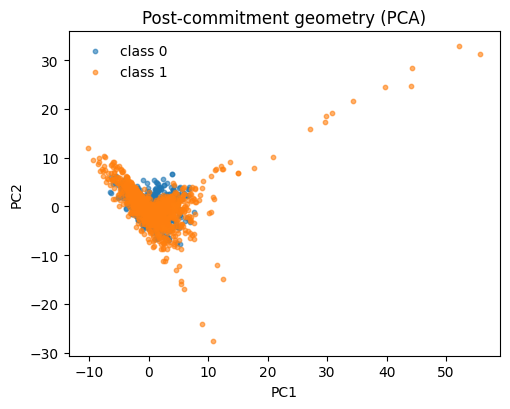

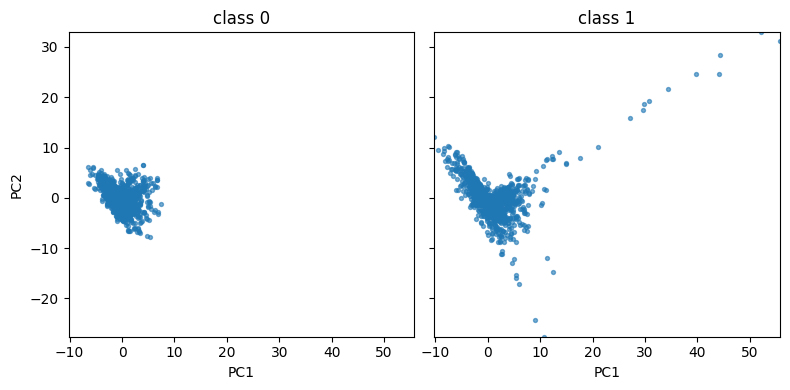

100%|██████████| 10/10 [01:46<00:00, 10.63s/it]


Explained variance ratio (first PCs): [0.0409 0.0375 0.0353 0.0269 0.0245]
Cumulative: [0.0409 0.0785 0.1138 0.1406 0.1651]


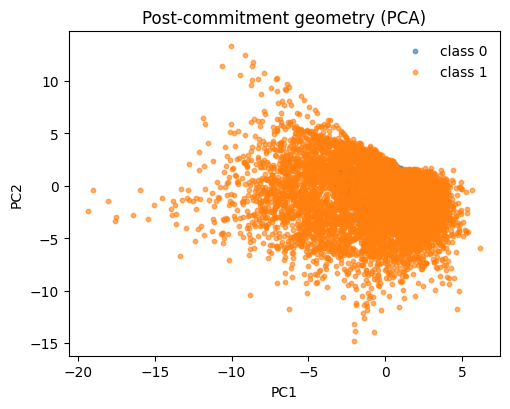

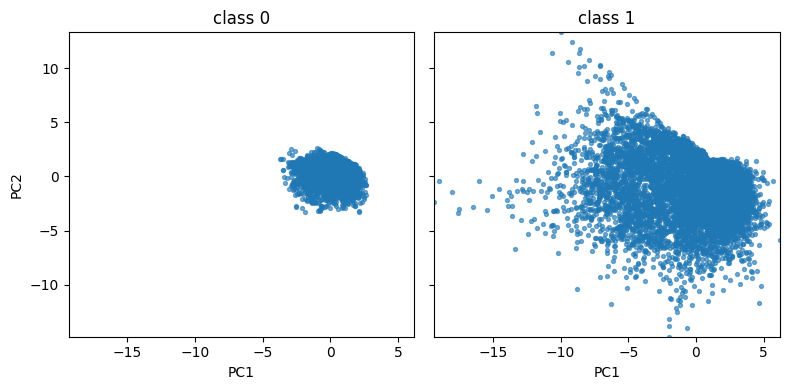

100%|██████████| 10/10 [00:17<00:00,  1.71s/it]


Explained variance ratio (first PCs): [0.0251 0.0233 0.021  0.0173 0.0169]
Cumulative: [0.0251 0.0484 0.0694 0.0867 0.1036]


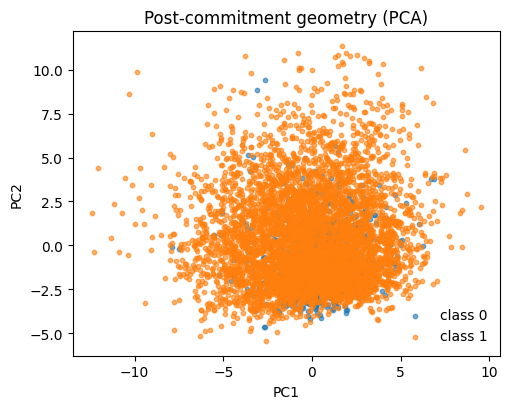

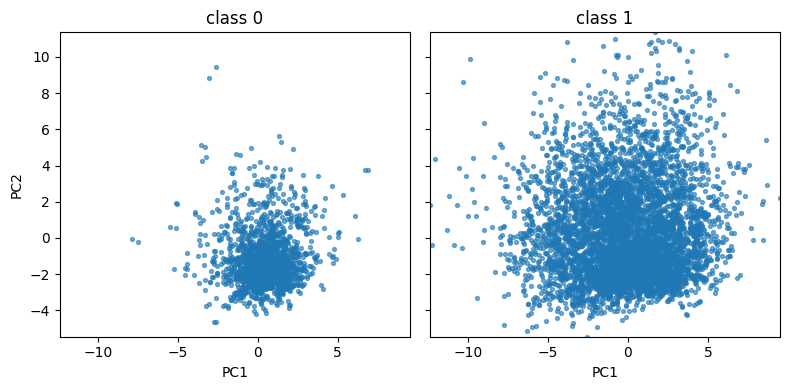

100%|██████████| 10/10 [00:01<00:00,  5.18it/s]


Explained variance ratio (first PCs): [0.0236 0.0214 0.0205 0.0199 0.0184]
Cumulative: [0.0236 0.0449 0.0654 0.0853 0.1037]


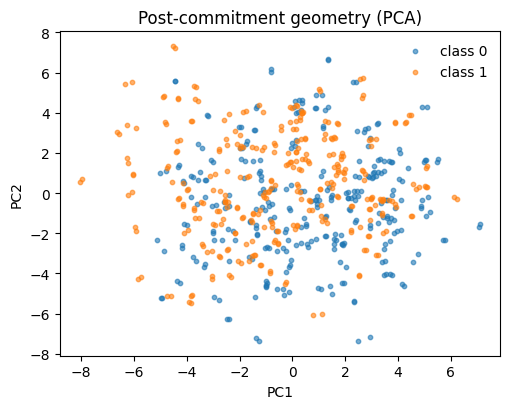

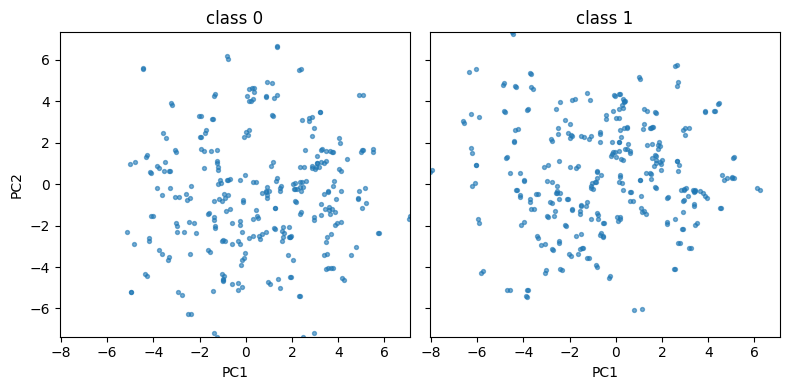

100%|██████████| 10/10 [00:00<00:00, 5050.94it/s]

Explained variance ratio (first PCs): [0.2204 0.1804 0.1175 0.0899 0.0751]
Cumulative: [0.2204 0.4008 0.5183 0.6082 0.6833]


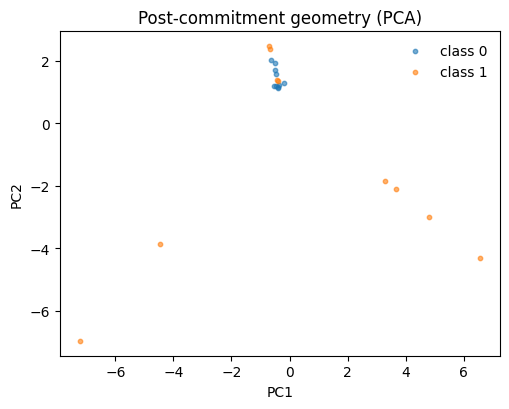

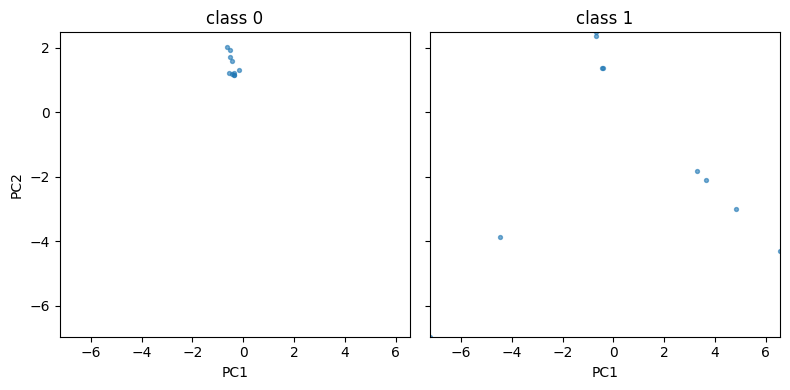

100%|██████████| 10/10 [01:49<00:00, 10.94s/it]


Explained variance ratio (first PCs): [0.0214 0.0203 0.0182 0.0128 0.0123]
Cumulative: [0.0214 0.0417 0.0599 0.0727 0.085 ]


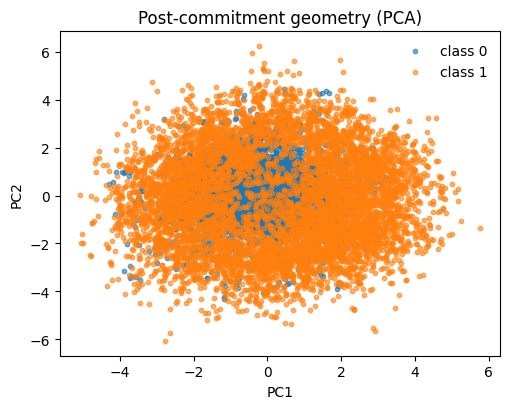

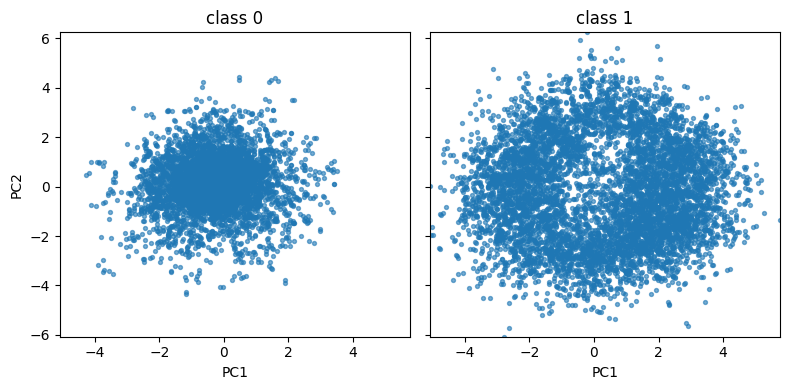

100%|██████████| 10/10 [00:00<00:00, 113.80it/s]


Explained variance ratio (first PCs): [0.0274 0.0226 0.0185 0.0174 0.0161]
Cumulative: [0.0274 0.0499 0.0684 0.0858 0.1019]


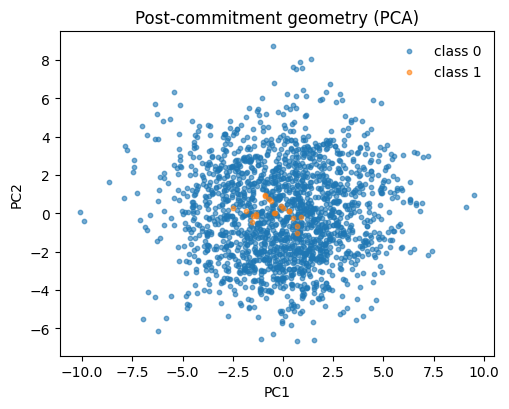

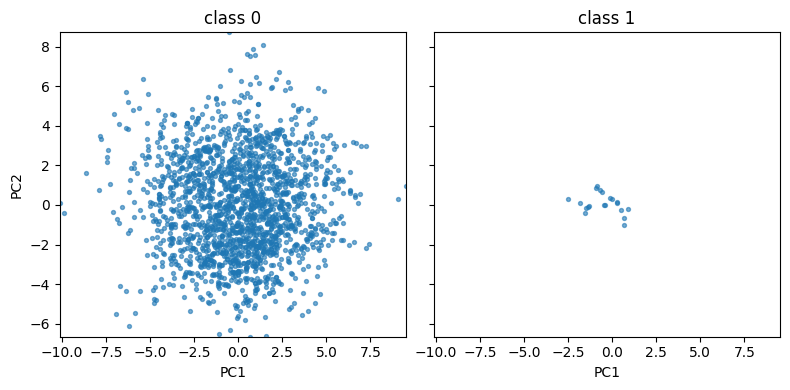

100%|██████████| 10/10 [00:16<00:00,  1.68s/it]


Explained variance ratio (first PCs): [0.0383 0.0305 0.0292 0.0206 0.0198]
Cumulative: [0.0383 0.0688 0.098  0.1185 0.1383]


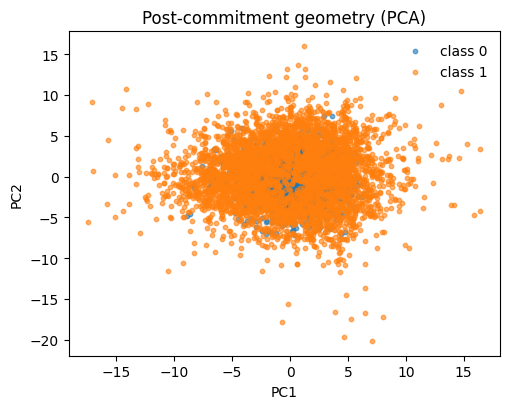

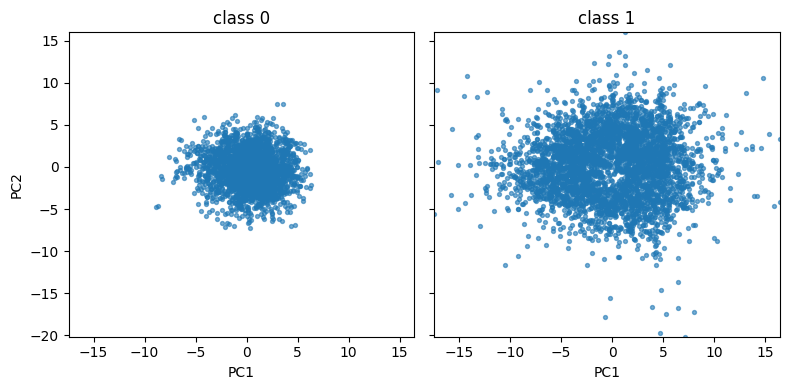

In [ ]:
taus = np.arange(0, 10)

for channel_idx in range(8):
    acts = activations[:, :, channel_idx]
    acts = acts.reshape(activations.shape[0], activations.shape[1], -1)
    acts_subset = acts[:10000]
    tc, tau_probes = estimate_tc_and_tau_probes(acts_subset, decisions, decision_step=20, taus=taus)
    X, y, meta = gather_postcommit_window(acts_subset, decisions, tc, tau_min=taus[0], tau_max=taus[1])
    # X = class_center(X, y)
    Z, info = pca_fit_transform(X, n_components=5)
    summarize_explained_variance(info)

    plot_pca_scatter(Z, y, dims=(0,1))
    plot_pca_split(Z, y, dims=(0,1))

# PCA + Jacobian

# set up input and trajectory collection, at leats

In [ ]:
import torch

def random_two_one_squares(x: torch.Tensor, *, tol: float = 0.0, gen=None):
    """
    Find two non-overlapping 2x2 squares of 1s in x and return:
      - dot_input: a zero-like mask with the two 2x2 squares set to 1
      - squares: list of length 2, each an (4, 2) tensor of (row, col) indices
    """
    if x.dim() != 2:
        raise ValueError("x must be a 2D tensor (H, W).")

    # cells equal to 1 (optionally within tolerance for floats)
    mask = (x == 1) if tol == 0 else ((x >= 1 - tol) & (x <= 1 + tol))

    H, W = mask.shape
    if H < 2 or W < 2:
        raise ValueError("x must be at least 2x2 to contain a 2x2 square.")

    # True where the 2x2 window (top-left at (i,j)) is all ones
    tl = mask[:-1, :-1]
    tr = mask[:-1,  1:]
    bl = mask[ 1:, :-1]
    br = mask[ 1:,  1:]
    top_left_ok = tl & tr & bl & br  # shape (H-1, W-1)

    candidates = torch.nonzero(top_left_ok, as_tuple=False)  # [(i,j) top-lefts], shape [K, 2]
    K = candidates.size(0)
    if K < 2:
        raise ValueError("Need at least two 2x2 squares of ones (non-overlapping).")

    # Randomize candidate order
    if gen is None:
        perm = torch.randperm(K, device=candidates.device)
    else:
        perm = torch.randperm(K, generator=gen, device=candidates.device)
    candidates = candidates[perm]

    # Helper to test overlap between two 2x2 squares given their top-lefts (i1,j1) and (i2,j2)
    # They overlap iff |i1 - i2| < 2 AND |j1 - j2| < 2 (they share at least one cell).
    def non_overlapping(a, b):
        return not (abs(int(a[0]) - int(b[0])) < 2 and abs(int(a[1]) - int(b[1])) < 2)

    # Pick first, then find a non-overlapping second
    first = candidates[0]
    second = None
    for c in candidates[1:]:
        if non_overlapping(first, c):
            second = c
            break

    if second is None:
        raise ValueError("Found multiple 2x2 squares, but none are non-overlapping. Try relaxing tol or input.")

    # Build output mask and explicit indices
    dot_input = torch.zeros_like(x, dtype=x.dtype)
    squares = []
    for tlrc in (first, second):
        i, j = int(tlrc[0]), int(tlrc[1])
        coords = torch.tensor([[i, j],
                               [i, j+1],
                               [i+1, j],
                               [i+1, j+1]], device=x.device, dtype=torch.long)
        squares.append(coords)
        dot_input[i, j] = 1
        dot_input[i, j+1] = 1
        dot_input[i+1, j] = 1
        dot_input[i+1, j+1] = 1

    return dot_input, squares


In [ ]:
input, label = list(test_loader)[0]
